<a href="https://colab.research.google.com/github/juanpospina/ESDA_code_git/blob/main/Clase_01/s01_script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 1 — El territorio como dato
## CM0866 · Análisis Exploratorio de Datos Espaciales y Econometría Espacial
**Universidad EAFIT · 2026**

---

Este notebook acompaña la primera sesión del curso. Su objetivo no es que domines todo el código de una vez — es que experimentes el flujo de trabajo que usaremos en todas las sesiones:

```
Cargar datos → Verificar CRS → Calcular → Visualizar → Exportar
```

**Ciudad base de este notebook:** Medellín. A partir de la Sesión 3 adaptarás el pipeline a tu ciudad de estudio cambiando solo los nombres de los archivos en la primera celda.

---

### Prerrequisitos
Ejecuta esto en tu terminal antes de abrir el notebook:
```bash
pip install geopandas matplotlib contextily
```

### Estructura de carpetas esperada
```
proyecto/
├── datos/
│      ├── morfologia/
│      │   └── manzanas_medellin_dane_2018.shp
│      └── ecologia/
│          └── zonas_verdes_medellin_osm.gpkg
├── outputs/
└── s01_primer_script.ipynb  ← este archivo
```

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 0 — Configuración: rutas de datos
# ─────────────────────────────────────────────────────────────────────────────
# Si cambias de ciudad, solo modifica estas rutas.
# El resto del notebook funciona igual.

CIUDAD = 'Medellín'   # nombre para títulos de mapas

RUTA_MANZANAS    = '../datos/morfologia/manzanas_medellin_dane_2018.zip'
#RUTA_VERDE       = 'datos/medellin/ecologia/zonas_verdes_medellin_osm.gpkg'
RUTA_OUTPUTS     = 'outputs/'

CRS_ANALISIS = 32618   # UTM Zona 18N / WGS84 — metros — pipeline internacional

import os
os.makedirs(RUTA_OUTPUTS, exist_ok=True)
print('✓ Configuración lista')

✓ Configuración lista


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 — Importar librerías
# ─────────────────────────────────────────────────────────────────────────────

import geopandas as gpd        # datos geoespaciales vectoriales
import matplotlib.pyplot as plt  # visualización estática
import contextily as ctx        # fondos de mapa (tiles)
import warnings
warnings.filterwarnings('ignore')

print(f'GeoPandas:   {gpd.__version__}')
print(f'Matplotlib:  {plt.matplotlib.__version__}')
print('✓ Librerías importadas')

GeoPandas:   1.0.1
Matplotlib:  3.9.2
✓ Librerías importadas


---
## Parte 1 — Cargar y explorar la capa de manzanas

La capa de manzanas del DANE es la **unidad espacial base** del proyecto integrador. Cada fila es una manzana; cada columna es un atributo del CENSO 2018.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 — Cargar la capa de manzanas
# ─────────────────────────────────────────────────────────────────────────────
# gpd.read_file() lee cualquier formato vectorial:
# .gpkg (GeoPackage), .shp (Shapefile), .geojson, .zip

manzanas = gpd.read_file(RUTA_MANZANAS)

print(f'Total de manzanas: {len(manzanas):,}')
print(f'Columnas ({len(manzanas.columns)}): {list(manzanas.columns)}')
print(f'CRS actual: {manzanas.crs}')
print()

# Las primeras filas — igual que pandas, con una columna 'geometry' adicional
manzanas.head(3)

Total de manzanas: 22,008
Columnas (109): ['COD_DANE_A', 'DPTO_CCDGO', 'MPIO_CCDGO', 'MPIO_CDPMP', 'CLAS_CCDGO', 'SETR_CCDGO', 'SETR_CCNCT', 'SECR_CCDGO', 'SECR_CCNCT', 'ZU_CCDGO', 'ZU_CDIVI', 'SETU_CCDGO', 'SETU_CCNCT', 'SECU_CCDGO', 'SECU_CCNCT', 'MANZ_CCDGO', 'AG_CCDGO', 'DATO_ANM', 'VERSION', 'AREA', 'LATITUD', 'LONGITUD', 'DENSIDAD', 'CTNENCUEST', 'TP3_1_SI', 'TP3_2_NO', 'TP3A_RI', 'TP3B_TCN', 'TP4_1_SI', 'TP4_2_NO', 'TP9_1_USO', 'TP9_2_USO', 'TP9_3_USO', 'TP9_4_USO', 'TP9_2_1_MI', 'TP9_2_2_MI', 'TP9_2_3_MI', 'TP9_2_4_MI', 'TP9_2_9_MI', 'TP9_3_1_NO', 'TP9_3_2_NO', 'TP9_3_3_NO', 'TP9_3_4_NO', 'TP9_3_5_NO', 'TP9_3_6_NO', 'TP9_3_7_NO', 'TP9_3_8_NO', 'TP9_3_9_NO', 'TP9_3_10_N', 'TP9_3_99_N', 'TVIVIENDA', 'TP14_1_TIP', 'TP14_2_TIP', 'TP14_3_TIP', 'TP14_4_TIP', 'TP14_5_TIP', 'TP14_6_TIP', 'TP15_1_OCU', 'TP15_2_OCU', 'TP15_3_OCU', 'TP15_4_OCU', 'TP16_HOG', 'TP19_EE_1', 'TP19_EE_2', 'TP19_EE_E1', 'TP19_EE_E2', 'TP19_EE_E3', 'TP19_EE_E4', 'TP19_EE_E5', 'TP19_EE_E6', 'TP19_EE_E9', 'TP19_ACU

,COD_DANE_A,DPTO_CCDGO,MPIO_CCDGO,MPIO_CDPMP,CLAS_CCDGO,SETR_CCDGO,SETR_CCNCT,SECR_CCDGO,SECR_CCNCT,ZU_CCDGO,...,TP51SUPERI,TP51POSTGR,TP51_13_ED,TP51_99_ED,CD_LC_CM,NMB_LC_CM,TP_LC_CM,Shape_Leng,Shape_Area,geometry
0,0507910000000000010102,05,079,05079,1,000,050791000,00,05079100000,000,...,67.0,0.0,8.0,10.0,None,None,None,0.003264,3.290700e-07,"POLYGON ((-75.33144 6.44118, -75.3314 6.44114,..."
1,0507910000000000010103,05,079,05079,1,000,050791000,00,05079100000,000,...,58.0,11.0,4.0,3.0,None,None,None,0.005251,4.880600e-07,"POLYGON ((-75.33094 6.44076, -75.33096 6.44074..."
2,0507910000000000010104,05,079,05079,1,000,050791000,00,05079100000,000,...,178.0,14.0,19.0,10.0,None,None,None,0.006750,6.467800e-07,"POLYGON ((-75.33026 6.44049, -75.33032 6.44042..."


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 — Verificar y corregir el CRS
# ─────────────────────────────────────────────────────────────────────────────
# REGLA: todo dato que entra al análisis debe estar en EPSG:32618
# (UTM Zona 18N / WGS84 — metros — pipeline internacional)
#
# ¿Por qué? En WGS84 (grados decimales) no se pueden calcular
# áreas ni distancias con sentido físico.

crs_actual = manzanas.crs.to_epsg()
print(f'CRS actual: EPSG:{crs_actual}')

if crs_actual != CRS_ANALISIS:
    manzanas = manzanas.to_crs(epsg=CRS_ANALISIS)
    print(f'→ Reproyectado a EPSG:{CRS_ANALISIS} (UTM Zona 18N / WGS84) ✓')
else:
    print(f'→ Ya está en EPSG:{CRS_ANALISIS} ✓')

print(f'CRS final: {manzanas.crs}')

CRS actual: EPSG:4326
→ Reproyectado a EPSG:32618 (UTM Zona 18N / WGS84) ✓
CRS final: EPSG:32618


---
## Parte 2 — Calcular área de cada manzana

En EPSG:32618 las coordenadas están en metros, así que `.geometry.area` devuelve metros cuadrados directamente. Esto no funcionaría en WGS84 (grados decimales).

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4 — Calcular área en m² y hectáreas
# ─────────────────────────────────────────────────────────────────────────────

manzanas['area_m2'] = manzanas.geometry.area          # metros cuadrados
manzanas['area_ha'] = manzanas['area_m2'] / 10_000    # hectáreas

print('─── Estadísticas de área de manzana ───')
print(f'Área media:      {manzanas.area_ha.mean():.3f} ha')
print(f'Área mediana:    {manzanas.area_ha.median():.3f} ha')
print(f'Área máxima:     {manzanas.area_ha.max():.2f} ha')
print(f'Área mínima:     {manzanas.area_ha.min():.4f} ha')
print(f'Área total:      {manzanas.area_ha.sum():,.1f} ha')
print()

# ¿Tiene sentido? Una manzana típica en ciudades colombianas mide 0.5 – 1.5 ha.
# Si el resultado fuera 0.0000089, estaría en grados cuadrados (CRS equivocado).
print('¿El área media tiene sentido físico para una manzana urbana?')
referencia = 0.85  # ha — valor de referencia para Medellín
diferencia = abs(manzanas.area_ha.mean() - referencia) / referencia * 100
print(f'Diferencia con referencia ({referencia} ha): {diferencia:.1f}%')

─── Estadísticas de área de manzana ───
Área media:      0.826 ha
Área mediana:    0.277 ha
Área máxima:     120.37 ha
Área mínima:     0.0026 ha
Área total:      18,181.4 ha

¿El área media tiene sentido físico para una manzana urbana?
Diferencia con referencia (0.85 ha): 2.8%


---
## Parte 3 — Primer mapa temático

Visualizamos la distribución espacial del área de las manzanas. Las zonas con manzanas grandes suelen corresponder a urbanizaciones planificadas de baja densidad; las zonas con manzanas pequeñas a tejido urbano histórico o informal denso.

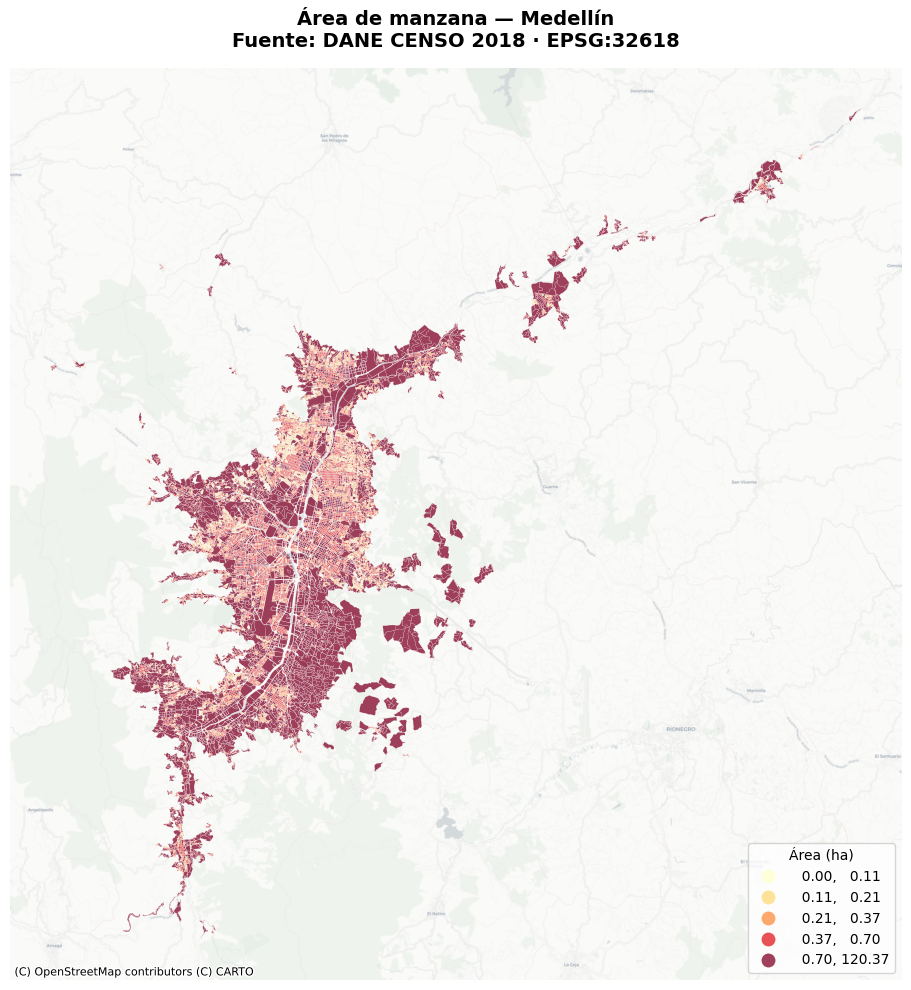

✓ Mapa guardado en: outputs/s01_mapa_area_manzana.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — Mapa de coropletas: área de manzana
# ─────────────────────────────────────────────────────────────────────────────
# Nota: contextily necesita que la capa esté en EPSG:3857 (Web Mercator)
# para superponer los tiles de fondo. Reproyectamos solo para el mapa,
# no modificamos la capa original.

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

manzanas.to_crs(epsg=3857).plot(
    column='area_ha',
    cmap='YlOrRd',               # amarillo → naranja → rojo
    scheme='quantiles',           # clasificación por cuantiles
    k=5,                          # 5 clases
    legend=True,
    legend_kwds={
        'title': 'Área (ha)',
        'fmt': '{:.2f}',
        'loc': 'lower right'
    },
    alpha=0.75,
    linewidth=0.1,
    edgecolor='white',
    ax=ax
)

# Fondo de mapa — requiere conexión a internet
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=13)
except Exception:
    print('⚠ Sin conexión — mapa sin fondo de referencia')

ax.set_title(
    f'Área de manzana — {CIUDAD}\nFuente: DANE CENSO 2018 · EPSG:{CRS_ANALISIS}',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_axis_off()
plt.tight_layout()

ruta_mapa = f'{RUTA_OUTPUTS}s01_mapa_area_manzana.png'
plt.savefig(ruta_mapa, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Mapa guardado en: {ruta_mapa}')

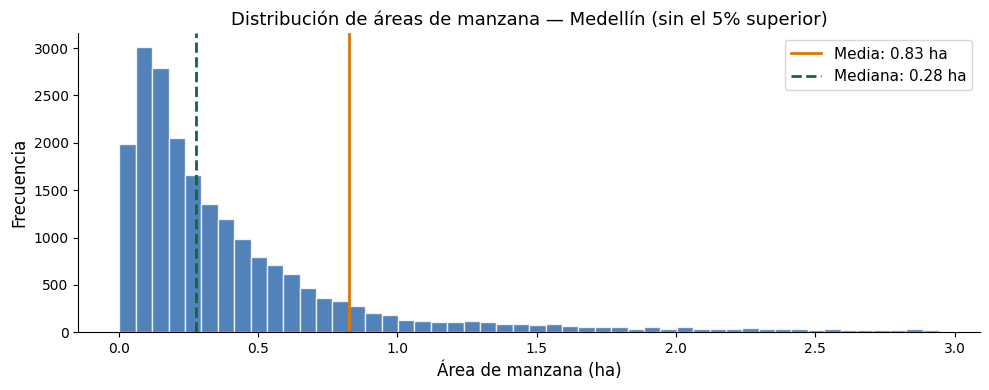

✓ Histograma guardado en: outputs/s01_histograma_area_manzana.png


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 — Histograma de la distribución de áreas
# ─────────────────────────────────────────────────────────────────────────────
# El mapa muestra la distribución espacial; el histograma muestra
# la distribución estadística. Ambos son necesarios para entender
# el fenómeno desde el ESDA.

fig, ax = plt.subplots(figsize=(10, 4))

# Recortar outliers extremos para la visualización
p95 = manzanas.area_ha.quantile(0.95)
datos_viz = manzanas.loc[manzanas.area_ha <= p95, 'area_ha']

ax.hist(datos_viz, bins=50, color='#2563A8', alpha=0.8, edgecolor='white')
ax.axvline(manzanas.area_ha.mean(),   color='#D97706', lw=2,
           label=f'Media: {manzanas.area_ha.mean():.2f} ha')
ax.axvline(manzanas.area_ha.median(), color='#166534', lw=2, linestyle='--',
           label=f'Mediana: {manzanas.area_ha.median():.2f} ha')

ax.set_xlabel('Área de manzana (ha)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title(f'Distribución de áreas de manzana — {CIUDAD} (sin el 5% superior)',
             fontsize=13)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

ruta_hist = f'{RUTA_OUTPUTS}s01_histograma_area_manzana.png'
plt.savefig(ruta_hist, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Histograma guardado en: {ruta_hist}')